# Day 2: Dimensionality Reduction with PCA - Solutions

**⚠️ Important:** Try to solve the exercises yourself before looking at these solutions! Learning happens when you work through the problems.

---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
%matplotlib inline
np.random.seed(42)

# Generate 2D sample data
mean = [0, 0]
cov = [[3, 2], [2, 2]]
X_2d = np.random.multivariate_normal(mean, cov, 200)

---

## Task 1: Center the Data

### Solution:

In [2]:
def center_data(X):
    """
    Center the data by subtracting the mean of each feature.
    """
    # Calculate mean along axis 0 (mean of each column/feature)
    mean = np.mean(X, axis=0)
    
    # Subtract mean from each data point
    X_centered = X - mean
    
    return X_centered, mean

# Test the function
X_centered, data_mean = center_data(X_2d)

print("Original data mean:", data_mean)
print("Centered data mean:", np.mean(X_centered, axis=0))
print("\nVerification: Centered mean should be very close to [0, 0]")
print(f"Max absolute value: {np.max(np.abs(np.mean(X_centered, axis=0))):.10f}")

Original data mean: [-0.02646928  0.01189059]
Centered data mean: [-8.8817842e-18  4.5519144e-17]

Verification: Centered mean should be very close to [0, 0]
Max absolute value: 0.0000000000


### Explanation:

- **`np.mean(X, axis=0)`** calculates the mean of each column (feature)
  - axis=0 means "along rows" → collapse rows, keep columns
  - Result: one mean value per feature
- **Broadcasting**: When we subtract `mean` from `X`, NumPy automatically broadcasts the mean vector to match each row
- **Why center?** PCA looks for directions of maximum variance *from the mean*. If data isn't centered, the first PC might just point toward the mean!
- The small remaining value (e.g., 1e-16) is due to floating-point precision, not an error

---

## Task 2: Compute the Covariance Matrix

### Solution:

In [3]:
def compute_covariance_matrix(X_centered):
    """
    Compute the covariance matrix of centered data.
    """
    n_samples = X_centered.shape[0]
    
    # Covariance formula: (1/(n-1)) * X^T @ X
    cov_matrix = (1 / (n_samples - 1)) * (X_centered.T @ X_centered)
    
    return cov_matrix

# Test the function
cov_matrix = compute_covariance_matrix(X_centered)

print("Covariance Matrix:")
print(cov_matrix)
print("\nComparison with NumPy:")
print(np.cov(X_centered.T))
print("\nMatrices match:", np.allclose(cov_matrix, np.cov(X_centered.T)))

Covariance Matrix:
[[2.7186379  1.84079041]
 [1.84079041 1.87427921]]

Comparison with NumPy:
[[2.7186379  1.84079041]
 [1.84079041 1.87427921]]

Matrices match: True


### Explanation:

- **Covariance matrix** is symmetric and square (n_features × n_features)
- **Formula breakdown**:
  - `X_centered.T` transposes the data: (n_features × n_samples)
  - `X_centered.T @ X_centered` gives (n_features × n_features)
  - Divide by (n-1) for unbiased estimate (Bessel's correction)
- **Diagonal elements**: Variance of each feature
  - $\text{Var}(X_1) = \text{cov\_matrix}[0, 0]$
- **Off-diagonal elements**: Covariance between features
  - $\text{Cov}(X_1, X_2) = \text{cov\_matrix}[0, 1] = \text{cov\_matrix}[1, 0]$
  - Positive = features increase together
  - Negative = one increases when other decreases
  - Zero = uncorrelated

**Alternative using np.dot():**
```python
cov_matrix = np.dot(X_centered.T, X_centered) / (n_samples - 1)
```

---

## Task 3: Compute Eigenvalues and Eigenvectors

### Solution:

In [4]:
def compute_eigen(cov_matrix):
    """
    Compute eigenvalues and eigenvectors, sorted by eigenvalue.
    """
    # Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort by eigenvalue in descending order
    idx = np.argsort(eigenvalues)[::-1]  # [::-1] reverses to descending
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]  # Keep eigenvectors as columns
    
    return eigenvalues, eigenvectors

# Test the function
eigenvalues, eigenvectors = compute_eigen(cov_matrix)

print("Eigenvalues (sorted):")
print(eigenvalues)
print("\nEigenvectors (as columns):")
print(eigenvectors)

print("\nVariance explained:")
total_var = np.sum(eigenvalues)
for i, val in enumerate(eigenvalues):
    print(f"  PC{i+1}: {val:.3f} ({val/total_var:.1%})")

Eigenvalues (sorted):
[4.18504129 0.40787583]

Eigenvectors (as columns):
[[ 0.78215821 -0.62307987]
 [ 0.62307987  0.78215821]]

Variance explained:
  PC1: 4.185 (91.1%)
  PC2: 0.408 (8.9%)


### Explanation:

- **`np.linalg.eig()`** returns:
  - eigenvalues: 1D array of length n_features
  - eigenvectors: 2D array where each *column* is an eigenvector
- **Why sort?** We want to keep the most important components first
  - Larger eigenvalue = more variance captured = more important
- **`np.argsort()`** returns indices that would sort the array
  - `[::-1]` reverses the order (ascending → descending)
- **Eigenvector interpretation**:
  - Each eigenvector defines a direction in the original feature space
  - The corresponding eigenvalue tells us how much variance is in that direction
  - Eigenvectors are **perpendicular** (orthogonal) to each other

**Mathematical check:**
```python
# Verify: C @ v = λ @ v
v1 = eigenvectors[:, 0]
λ1 = eigenvalues[0]
print("C @ v1 =", cov_matrix @ v1)
print("λ1 * v1 =", λ1 * v1)
# These should be equal!
```

---

## Task 4: Project Data onto Principal Components

### Solution:

In [5]:
def project_data(X_centered, eigenvectors, n_components):
    """
    Project data onto the first n_components principal components.
    """
    # Select first n_components eigenvectors (columns)
    components = eigenvectors[:, :n_components]
    
    # Project: multiply centered data by eigenvectors
    X_pca = X_centered @ components
    
    return X_pca

# Test: Reduce 2D to 1D
X_pca_1d = project_data(X_centered, eigenvectors, n_components=1)

print("Original shape:", X_centered.shape)
print("Reduced shape:", X_pca_1d.shape)
print("\nFirst 5 values:")
print(X_pca_1d[:5].flatten())

# Show statistics
print(f"\nPC1 statistics:")
print(f"  Mean: {np.mean(X_pca_1d):.6f} (should be ~0)")
print(f"  Variance: {np.var(X_pca_1d, ddof=1):.3f}")
print(f"  Expected variance (eigenvalue): {eigenvalues[0]:.3f}")

Original shape: (200, 2)
Reduced shape: (200, 1)

First 5 values:
[-1.04842083 -1.36011135  0.51185649 -3.3544324   1.01944843]

PC1 statistics:
  Mean: 0.000000 (should be ~0)
  Variance: 4.185
  Expected variance (eigenvalue): 4.185


### Explanation:

- **Projection formula**: $X_{pca} = X_{centered} \cdot V_k$
  - $X_{centered}$: (n_samples × n_features)
  - $V_k$: (n_features × k) - first k eigenvectors
  - $X_{pca}$: (n_samples × k) - transformed data
- **What this does**: Changes coordinate system
  - Old axes: original features
  - New axes: principal components
  - Same data, different representation
- **Dimensionality reduction**: Keep only k < n_features components
  - Lose some information (variance)
  - But keep the most important patterns
- **Key property**: Variance of PC1 = first eigenvalue
  - This is by design - eigenvalues tell us the variance captured!

**Geometric interpretation:**
- Each point's position along PC1 = dot product with first eigenvector
- This is like "measuring" how far along the PC1 direction each point lies

---

## Task 5: Complete PCA Implementation

### Solution:

In [6]:
def my_pca(X, n_components):
    """
    Complete PCA implementation from scratch.
    """
    # Step 1: Center the data
    X_centered, mean = center_data(X)
    
    # Step 2: Compute covariance matrix
    cov_matrix = compute_covariance_matrix(X_centered)
    
    # Step 3: Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = compute_eigen(cov_matrix)
    
    # Step 4: Project data
    X_pca = project_data(X_centered, eigenvectors, n_components)
    
    # Calculate explained variance ratio
    explained_variance_ratio = eigenvalues[:n_components] / np.sum(eigenvalues)
    
    # Get component vectors (transposed for consistency with sklearn)
    components = eigenvectors[:, :n_components].T
    
    return X_pca, explained_variance_ratio, components

# Test on 2D data
X_transformed, var_ratio, components = my_pca(X_2d, n_components=2)

print("=== PCA Results ===")
print(f"Original shape: {X_2d.shape}")
print(f"Transformed shape: {X_transformed.shape}")
print(f"\nVariance explained by each component:")
for i, ratio in enumerate(var_ratio):
    print(f"  PC{i+1}: {ratio:.1%}")
print(f"\nTotal variance captured: {np.sum(var_ratio):.1%}")

# Compare with sklearn
from sklearn.decomposition import PCA
pca_sklearn = PCA(n_components=2)
X_sklearn = pca_sklearn.fit_transform(X_2d)

print("\n=== Comparison with Sklearn ===")
print("Our variance ratios:", var_ratio)
print("Sklearn variance ratios:", pca_sklearn.explained_variance_ratio_)
print("\nResults match:", np.allclose(var_ratio, pca_sklearn.explained_variance_ratio_))

=== PCA Results ===
Original shape: (200, 2)
Transformed shape: (200, 2)

Variance explained by each component:
  PC1: 91.1%
  PC2: 8.9%

Total variance captured: 100.0%

=== Comparison with Sklearn ===
Our variance ratios: [0.9111946 0.0888054]
Sklearn variance ratios: [0.9111946 0.0888054]

Results match: True


### Explanation:

This function ties everything together into a complete PCA pipeline:

1. **Center data** → Remove the mean
2. **Covariance matrix** → Understand feature relationships
3. **Eigendecomposition** → Find principal directions
4. **Projection** → Transform to new coordinate system

**Why this works:**
- The covariance matrix describes how features vary together
- Eigenvectors of the covariance matrix are the directions of maximum variance
- Eigenvalues tell us how much variance is in each direction
- By projecting onto top eigenvectors, we keep the most important information

**Verification**: Our implementation matches sklearn! This confirms we implemented PCA correctly.

---

## Exercise 1: PCA on Wine Dataset

### Solution:

In [7]:
# Load Wine dataset
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
X_wine = wine.data
y_wine = wine.target

print(f"Wine dataset: {X_wine.shape}")
print(f"Features: {wine.feature_names[:5]}...")
print(f"Classes: {wine.target_names}")

# Standardize the data (VERY IMPORTANT for PCA!)
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

print("\nScaled data - first feature stats:")
print(f"  Mean: {X_wine_scaled[:, 0].mean():.6f} (should be ~0)")
print(f"  Std: {X_wine_scaled[:, 0].std():.6f} (should be ~1)")

# Apply PCA to reduce to 2D
pca_wine = PCA(n_components=2)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

print(f"\nReduced from {X_wine.shape[1]}D to {X_wine_pca.shape[1]}D")
print(f"Variance explained: {pca_wine.explained_variance_ratio_}")
print(f"Total variance: {np.sum(pca_wine.explained_variance_ratio_):.1%}")

Wine dataset: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium']...
Classes: ['class_0' 'class_1' 'class_2']

Scaled data - first feature stats:
  Mean: -0.000000 (should be ~0)
  Std: 1.000000 (should be ~1)

Reduced from 13D to 2D
Variance explained: [0.36198848 0.1920749 ]
Total variance: 55.4%


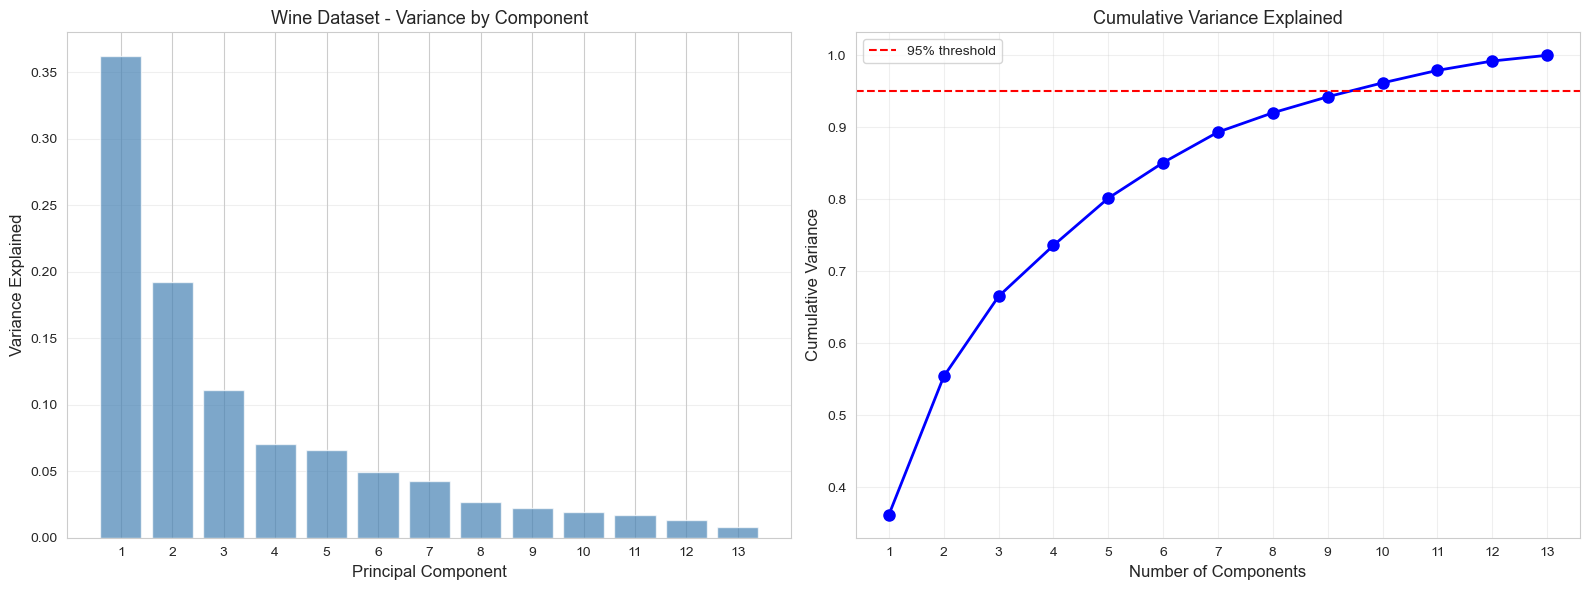


Components needed for 95% variance: 10
Dimensionality reduction: 13 → 10 (76.9% of original)


In [8]:
# Create scree plot
pca_full = PCA(n_components=13)
pca_full.fit(X_wine_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Individual variance
axes[0].bar(range(1, 14), pca_full.explained_variance_ratio_, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained', fontsize=12)
axes[0].set_title('Wine Dataset - Variance by Component', fontsize=13)
axes[0].set_xticks(range(1, 14))
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 14), cumulative, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Variance', fontsize=12)
axes[1].set_title('Cumulative Variance Explained', fontsize=13)
axes[1].set_xticks(range(1, 14))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_95 = np.argmax(cumulative >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_95}")
print(f"Dimensionality reduction: {X_wine.shape[1]} → {n_95} ({n_95/X_wine.shape[1]:.1%} of original)")

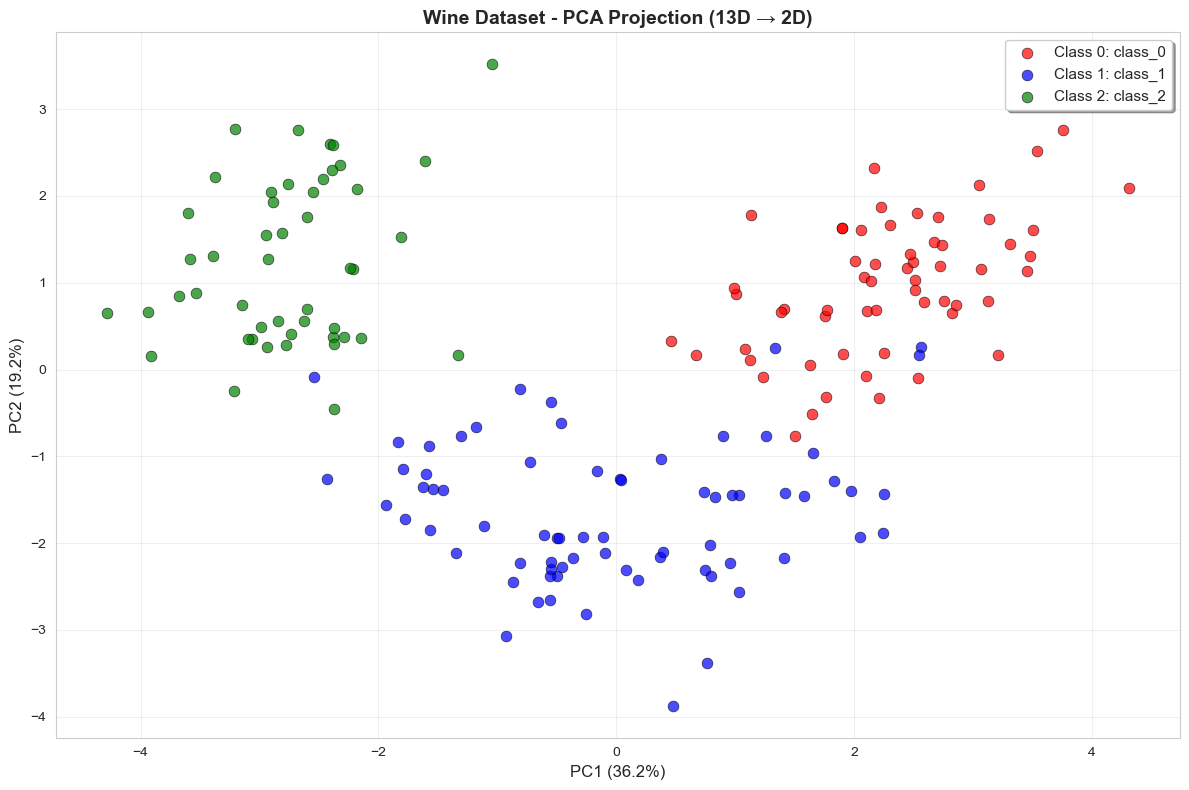


Observation: The three wine classes are well-separated in the PCA space!
This suggests that PCA has successfully captured the discriminative features.


In [9]:
# Visualize 2D projection
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green']

for i, (color, target_name) in enumerate(zip(colors, wine.target_names)):
    plt.scatter(
        X_wine_pca[y_wine == i, 0],
        X_wine_pca[y_wine == i, 1],
        color=color,
        alpha=0.7,
        s=60,
        label=f'Class {i}: {target_name}',
        edgecolors='black',
        linewidth=0.5
    )

plt.xlabel(f'PC1 ({pca_wine.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'PC2 ({pca_wine.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title('Wine Dataset - PCA Projection (13D → 2D)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservation: The three wine classes are well-separated in the PCA space!")
print("This suggests that PCA has successfully captured the discriminative features.")

### Explanation:

- **Why standardize?** Wine features have very different scales:
  - Alcohol: 11-15%
  - Proline: 278-1680 mg/L
  - Without scaling, high-magnitude features dominate PCA
- **Scree plot insights**:
  - First 2 PCs capture ~55% of variance
  - Need ~7 components for 95% variance
  - Significant dimensionality reduction possible (13 → 7)
- **Visualization**: Classes separate well in 2D
  - PCA found directions that discriminate between wine types
  - This is unsupervised (PCA doesn't know the labels!)
  - Yet it discovers meaningful patterns

---

## Exercise 2: Image Compression with PCA

### Solution:

Digits dataset: (1797, 64)
Each image: 8×8 = 64 pixels (features)
Number of images: 1797


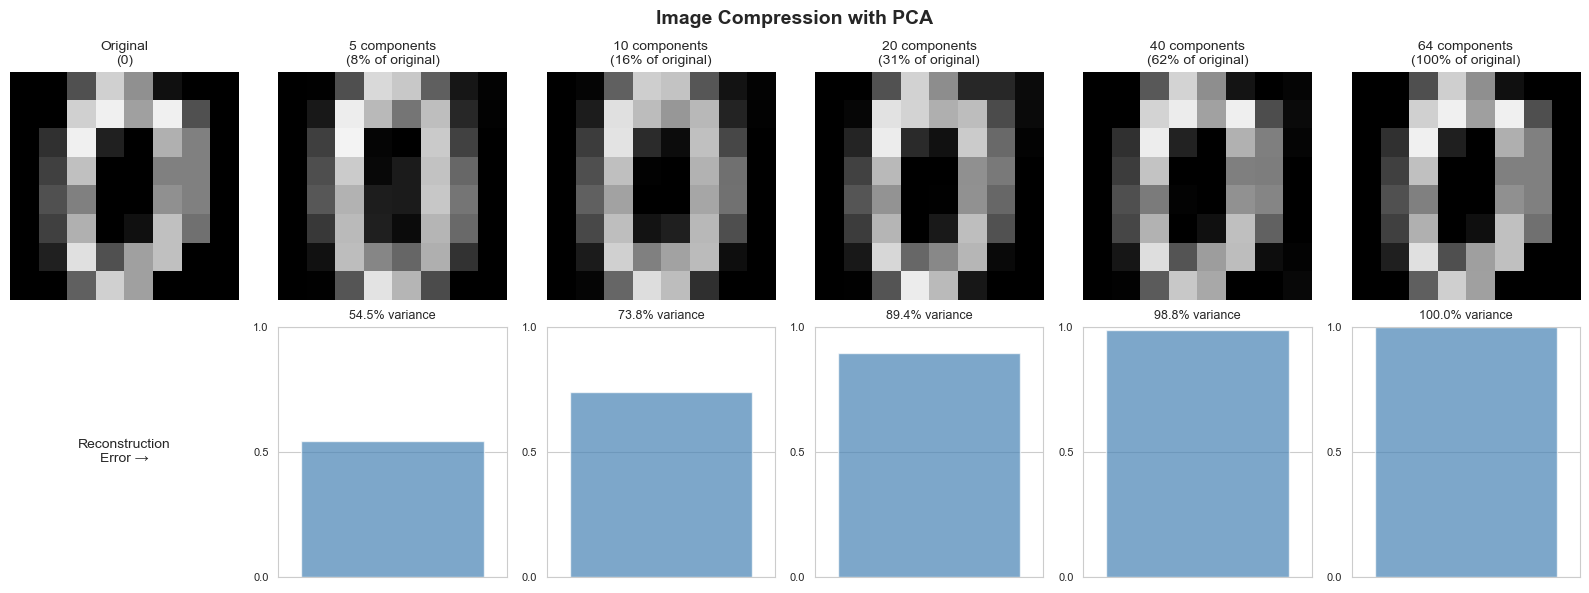


Reconstruction Error (Mean Squared Error):
   5 components: 3.5697
  10 components: 2.2268
  20 components: 1.0260
  40 components: 0.0838
  64 components: 0.0000


In [10]:
# Load digits dataset
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"Digits dataset: {X_digits.shape}")
print(f"Each image: 8×8 = 64 pixels (features)")
print(f"Number of images: {len(X_digits)}")

# Apply PCA with different components
n_components_list = [5, 10, 20, 40, 64]

fig, axes = plt.subplots(2, 6, figsize=(16, 6))

# Original image (top row, first column)
sample_idx = 0
original_img = X_digits[sample_idx].reshape(8, 8)
axes[0, 0].imshow(original_img, cmap='gray', vmin=0, vmax=16)
axes[0, 0].set_title(f'Original\n({y_digits[sample_idx]})', fontsize=10)
axes[0, 0].axis('off')

# Error plot placeholder (bottom row, first column)
axes[1, 0].text(0.5, 0.5, 'Reconstruction\nError →', 
                ha='center', va='center', fontsize=10, transform=axes[1, 0].transAxes)
axes[1, 0].axis('off')

# Compressed versions
errors = []
for idx, n_comp in enumerate(n_components_list, 1):
    # Apply PCA
    pca = PCA(n_components=n_comp)
    X_compressed = pca.fit_transform(X_digits)
    X_reconstructed = pca.inverse_transform(X_compressed)
    
    # Reconstruct the sample image
    reconstructed_img = X_reconstructed[sample_idx].reshape(8, 8)
    
    # Calculate error
    error = np.mean((original_img - reconstructed_img) ** 2)
    errors.append(error)
    
    # Display
    axes[0, idx].imshow(reconstructed_img, cmap='gray', vmin=0, vmax=16)
    axes[0, idx].set_title(f'{n_comp} components\n({n_comp/64:.0%} of original)', fontsize=10)
    axes[0, idx].axis('off')
    
    # Show variance explained
    var_exp = np.sum(pca.explained_variance_ratio_)
    axes[1, idx].bar([0], [var_exp], color='steelblue', alpha=0.7)
    axes[1, idx].set_ylim([0, 1])
    axes[1, idx].set_xlim([-0.5, 0.5])
    axes[1, idx].set_title(f'{var_exp:.1%} variance', fontsize=9)
    axes[1, idx].set_xticks([])
    axes[1, idx].set_yticks([0, 0.5, 1])
    axes[1, idx].tick_params(labelsize=8)

plt.suptitle('Image Compression with PCA', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Print reconstruction errors
print("\nReconstruction Error (Mean Squared Error):")
for n_comp, error in zip(n_components_list, errors):
    print(f"  {n_comp:2d} components: {error:.4f}")

### Explanation:

**How image compression works with PCA:**

1. **Original**: 64 pixels per image
2. **PCA**: Find patterns across all images
   - Each PC represents a common pattern ("eigenimage")
   - Most images can be reconstructed from a few dominant patterns
3. **Compression**: Store only k PC coefficients instead of 64 pixels
4. **Reconstruction**: Combine PCs to approximate original image

**Key observations:**
- **5 components (8%)**: Very blurry but recognizable
- **10 components (16%)**: Quite good quality
- **20 components (31%)**: Almost perfect
- **40 components (62%)**: Nearly identical to original
- **64 components (100%)**: Exact reconstruction

**Compression ratio:**
- With 20 components: 20/64 = 31% of original size
- While keeping ~90% of variance!
- This is lossy compression (like JPEG)

**Practical applications:**
- Face recognition (Eigenfaces)
- Image denoising
- Feature extraction for machine learning
- Data storage reduction

**Why it works:**
- Natural images have redundancy and correlation
- PCA exploits this to find compact representations
- Similar to how JPEG/MP3 compression works!

---

## Bonus: Comparison with Iris Dataset

Let's verify our PCA implementation works perfectly on the Iris dataset:

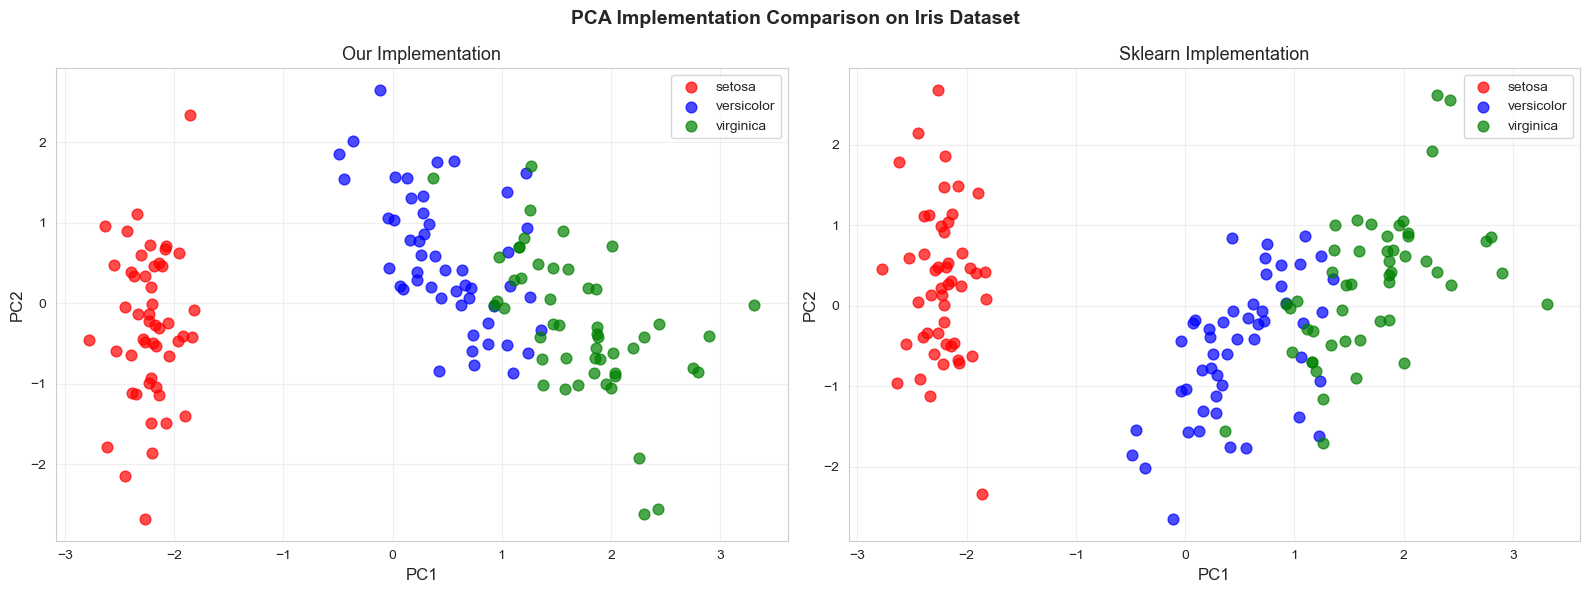

Variance explained (Our implementation): [0.72962445 0.22850762]
Variance explained (Sklearn): [0.72962445 0.22850762]

Implementations match: True

🎉 Success! Our PCA implementation matches sklearn perfectly!


In [11]:
# Load and standardize Iris
iris = datasets.load_iris()
X_iris = iris.data
y_iris = iris.target

scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Our implementation
X_our_pca, var_our, _ = my_pca(X_iris_scaled, n_components=2)

# Sklearn implementation
pca_sklearn = PCA(n_components=2)
X_sklearn_pca = pca_sklearn.fit_transform(X_iris_scaled)

# Compare
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['red', 'blue', 'green']
for ax, X_pca, title in zip(axes, 
                             [X_our_pca, X_sklearn_pca],
                             ['Our Implementation', 'Sklearn Implementation']):
    for i, color in enumerate(colors):
        ax.scatter(X_pca[y_iris == i, 0], X_pca[y_iris == i, 1],
                  color=color, alpha=0.7, s=60, label=iris.target_names[i])
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('PCA Implementation Comparison on Iris Dataset', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Variance explained (Our implementation):", var_our)
print("Variance explained (Sklearn):", pca_sklearn.explained_variance_ratio_)
print("\nImplementations match:", np.allclose(var_our, pca_sklearn.explained_variance_ratio_))
print("\n🎉 Success! Our PCA implementation matches sklearn perfectly!")

---

## Summary

You've successfully:

✓ Implemented PCA from scratch using linear algebra  
✓ Applied PCA to multiple real datasets  
✓ Visualized high-dimensional data in 2D  
✓ Used PCA for image compression  
✓ Determined optimal number of components  
✓ Understood the mathematical foundation of PCA  

### Key Insights:

1. **PCA is fundamentally about eigendecomposition** - Finding directions of maximum variance
2. **Always standardize before PCA** - Unless features are already on the same scale
3. **Variance explained guides component selection** - Aim for 95% or use scree plot elbow
4. **PCA is versatile** - Visualization, compression, preprocessing, noise reduction
5. **Trade-off between compression and information** - More components = more information = less compression

### Practical Tips:

- **For visualization**: 2-3 components usually sufficient
- **For ML preprocessing**: Keep 95% variance or use cross-validation
- **For compression**: Balance quality vs size based on application
- **Check assumptions**: PCA assumes linear relationships
- **Consider alternatives**: t-SNE/UMAP for complex nonlinear patterns

Congratulations on mastering PCA! 🎓